<a href="https://colab.research.google.com/github/patjiang/ConvolutionalSelfAttention/blob/main/MNIST_CSA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title Clone Repo, run test
!git clone https://github.com/patjiang/ConvolutionalSelfAttention.git > /dev/null 2>&1
!python ConvolutionalSelfAttention/tests.py

from IPython.display import HTML
from base64 import b64encode
import os
from glob import glob

conv3d CSA passed
conv2d CSA passed
SA test passed
all tests passed


In [ ]:
#@title import MNIST dataset
import torch
from torchvision import datasets, transforms

transform = transforms.Compose([transforms.ToTensor(),
                              transforms.Normalize((0.5,), (0.5,)),
                              ])
# Download and load the training data
trainset = datasets.MNIST('/content/MNIST_data/', download=True, train=True, transform=transform)
testset = datasets.MNIST('/content/MNIST_data/', download=True, train=False, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 11.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 338kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.18MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.62MB/s]


### Benchmarking

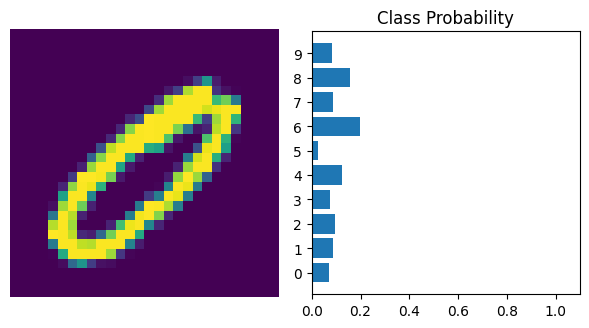

In [ ]:
#@title do initial tests for data
import torch
import torch.nn as nn
import torch.nn.functional as F
from ConvolutionalSelfAttention.utils.modules import *
from ConvolutionalSelfAttention.utils.benchmark_models import *
from ConvolutionalSelfAttention.utils.benchmark_pipe import *
from ConvolutionalSelfAttention.utils.data_load_test import *
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
model = MNIST_CSA_1_layer(1, (28*28))

# Grab some data
dataiter = iter(trainloader)
images, labels = next(dataiter)
images.resize_(64, 1, 1, 28, 28)
img_idx = 0
pred, embed = model.forward(images[img_idx,:])
ps = F.log_softmax(pred, dim=1)
img = images[img_idx]

view_classify(img.view(1, 28, 28), torch.exp(ps))

### Test Toy Models

In [ ]:
#@title train a one layer model
model = MNIST_CSA_1_layer(1, (28*28)).to('cuda')
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=True)
folder = 'lats'
csa_1_loss, csa_1_time = run_test(model, trainloader, testloader, folder)

image_folder = f'/content/{folder}'

output_path = f'/content/{folder}/vid_out.mp4'

!ffmpeg -r 10 -i "{image_folder}/frame_%03d.png" -vcodec libx264 -pix_fmt yuv420p "{output_path}" > /dev/null 2>&1

video_path = f'/content/{folder}/vid_out.mp4'

mp4 = open(video_path,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
torch.save(model.state_dict(), 'csa_1.pt')

HTML(f"""
<video width=640 controls>
    <source src="{data_url}" type="video/mp4">
</video>
""")

In [ ]:
#@title train a two layer model
model = MNIST_CSA_2_layer(1, (28*28)).to('cuda')
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=True)
folder = 'lats2'
csa_2_loss, csa_2_time = run_test(model, trainloader, testloader, folder)

image_folder = f'/content/{folder}'

output_path = f'/content/{folder}/vid_out.mp4'

!ffmpeg -r 10 -i "{image_folder}/frame_%03d.png" -vcodec libx264 -pix_fmt yuv420p "{output_path}" > /dev/null 2>&1

video_path = f'/content/{folder}/vid_out.mp4'

mp4 = open(video_path,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width=640 controls>
    <source src="{data_url}" type="video/mp4">
</video>
""")
torch.save(model.state_dict(), 'csa_2.pt')
HTML(f"""
<video width=640 controls>
    <source src="{data_url}" type="video/mp4">
</video>
""")

In [ ]:
#@title train a one layer model (no reduction)
model = MNIST_CSA_1_layer_full(1, (28*28)).to('cuda')
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=True)
folder = 'latsf'
csa_1f_loss, csa_1f_time = run_test(model, trainloader, testloader, folder)

image_folder = f'/content/{folder}'

output_path = f'/content/{folder}/vid_out.mp4'

!ffmpeg -r 10 -i "{image_folder}/frame_%03d.png" -vcodec libx264 -pix_fmt yuv420p "{output_path}" > /dev/null 2>&1

video_path = f'/content/{folder}/vid_out.mp4'

mp4 = open(video_path,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
torch.save(model.state_dict(), 'csa_1f.pt')

HTML(f"""
<video width=640 controls>
    <source src="{data_url}" type="video/mp4">
</video>
""")

In [ ]:
#@title train a two layer model (no reduction)
model = MNIST_CSA_2_layer_full(1, (28*28)).to('cuda')
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=True)
folder = 'lats2f'
csa_2f_loss, csa_2f_time = run_test(model, trainloader, testloader, folder)

image_folder = f'/content/{folder}'

output_path = f'/content/{folder}/vid_out.mp4'

!ffmpeg -r 10 -i "{image_folder}/frame_%03d.png" -vcodec libx264 -pix_fmt yuv420p "{output_path}" > /dev/null 2>&1

video_path = f'/content/{folder}/vid_out.mp4'

mp4 = open(video_path,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
torch.save(model.state_dict(), 'csa_2f.pt')

HTML(f"""
<video width=640 controls>
    <source src="{data_url}" type="video/mp4">
</video>
""")

In [ ]:
#@title train a one layer self attention no convolution
model = MNIST_SA_1_layer(1, (28*28)).to('cuda')
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=True)
folder = 'lats_1'
lsa_1_loss, lsa_1_time = run_test(model, trainloader, testloader, folder, 0.00001)

image_folder = f'/content/{folder}'

output_path = f'/content/{folder}/vid_out.mp4'

!ffmpeg -r 10 -i "{image_folder}/frame_%03d.png" -vcodec libx264 -pix_fmt yuv420p "{output_path}" > /dev/null 2>&1

video_path = f'/content/{folder}/vid_out.mp4'

mp4 = open(video_path,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
torch.save(model.state_dict(), 'lsa_1.pt')
HTML(f"""
<video width=640 controls>
    <source src="{data_url}" type="video/mp4">
</video>
""")

In [ ]:
#@title train a two layer self attention no convolution
model = MNIST_SA_2_layer(1, (28*28)).to('cuda')
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=True)
folder = 'lats_2'
lsa_2_loss, lsa_2_time = run_test(model, trainloader, testloader, folder, 0.00001)

image_folder = f'/content/{folder}'

output_path = f'/content/{folder}/vid_out.mp4'

!ffmpeg -r 10 -i "{image_folder}/frame_%03d.png" -vcodec libx264 -pix_fmt yuv420p "{output_path}" > /dev/null 2>&1

video_path = f'/content/{folder}/vid_out.mp4'

mp4 = open(video_path,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()


torch.save(model.state_dict(), 'lsa_2.pt')
HTML(f"""
<video width=640 controls>
    <source src="{data_url}" type="video/mp4">
</video>
""")

In [ ]:
#@title train a CNN
model = CNN().to('cuda')
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=True)
folder = 'lat_cnn'
cnn_1_loss, cnn_1_time = run_test(model, trainloader, testloader, 'lat_cnn')

image_folder = f'/content/{folder}'

output_path = f'/content/{folder}/vid_out.mp4'

!ffmpeg -r 10 -i "{image_folder}/frame_%03d.png" -vcodec libx264 -pix_fmt yuv420p "{output_path}" > /dev/null 2>&1

video_path = f'/content/{folder}/vid_out.mp4'

mp4 = open(video_path,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()


torch.save(model.state_dict(), 'cnn_1.pt')

HTML(f"""
<video width=640 controls>
    <source src="{data_url}" type="video/mp4">
</video>
""")

In [ ]:
#@title train a larger CNN
model = CNN_torch().to('cuda')
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=True)
folder = 'lats_cnn_t'
cnn_2_loss, cnn_2_time = run_test(model, trainloader, testloader, folder, 0.00002)

image_folder = f'/content/{folder}'

output_path = f'/content/{folder}/vid_out.mp4'

!ffmpeg -r 10 -i "{image_folder}/frame_%03d.png" -vcodec libx264 -pix_fmt yuv420p "{output_path}" > /dev/null 2>&1

video_path = f'/content/{folder}/vid_out.mp4'

mp4 = open(video_path,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()


torch.save(model.state_dict(), 'cnn_2.pt')

HTML(f"""
<video width=640 controls>
    <source src="{data_url}" type="video/mp4">
</video>
""")

In [ ]:
#@title train LeNet
model = LeNet().to('cuda')
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=True)
folder = 'lats_lenet'
lenet_loss, lenet_time = run_test(model, trainloader, testloader, folder, 0.00002)

image_folder = f'/content/{folder}'

output_path = f'/content/{folder}/vid_out.mp4'

!ffmpeg -r 10 -i "{image_folder}/frame_%03d.png" -vcodec libx264 -pix_fmt yuv420p "{output_path}" > /dev/null 2>&1

video_path = f'/content/{folder}/vid_out.mp4'

mp4 = open(video_path,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()


torch.save(model.state_dict(), 'lenet.pt')

HTML(f"""
<video width=640 controls>
    <source src="{data_url}" type="video/mp4">
</video>
""")

### Make figures

Number of Parameters from Convolutional Self Attention (1 layer): 2154
Number of Parameters from Convolutional Self Attention (2 layers): 868
Number of Parameters from Convolutional Self Attention full(1 layer): 2595
Number of Parameters from Convolutional Self Attention full (2 layers): 1309
Number of Parameters from Linear Self Attention (1 layer): 310278
Number of Parameters from Linear Self Attention (2 layers): 328261
Number of Parameters from Convolutional Neural Network (simple): 9098
Number of Parameters from Convolutional Neural Network (torch example): 431080
Number of Parameters from Convolutional Neural Network (torch example): 431080


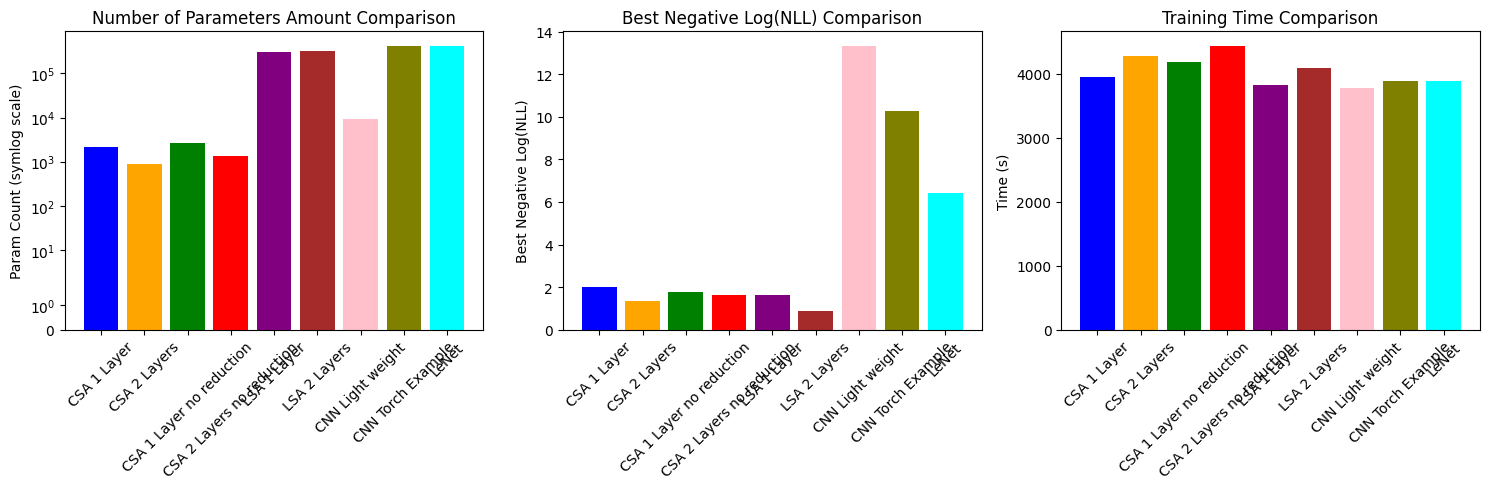

In [ ]:
#@title compare number of parameters

dummy_inp = torch.rand(1, 1, 28, 28)

model = MNIST_CSA_1_layer(1, (28*28))
_ = model(dummy_inp)
total_params = sum(param.numel() for param in model.parameters())
print(f"Number of Parameters from Convolutional Self Attention (1 layer): {total_params}")
csa_1 = total_params

model = MNIST_CSA_2_layer(1, (28*28))
_ = model(dummy_inp)
total_params = sum(param.numel() for param in model.parameters())
print(f"Number of Parameters from Convolutional Self Attention (2 layers): {total_params}")
csa_2 = total_params

model = MNIST_CSA_1_layer_full(1, (28*28))
_ = model(dummy_inp)
total_params = sum(param.numel() for param in model.parameters())
print(f"Number of Parameters from Convolutional Self Attention full(1 layer): {total_params}")
csa_1f = total_params

model = MNIST_CSA_2_layer_full(1, (28*28))
_ = model(dummy_inp)
total_params = sum(param.numel() for param in model.parameters())
print(f"Number of Parameters from Convolutional Self Attention full (2 layers): {total_params}")
csa_2f = total_params

model = MNIST_SA_1_layer(1, (28*28))
_ = model(dummy_inp)
total_params = sum(param.numel() for param in model.parameters())
print(f"Number of Parameters from Linear Self Attention (1 layer): {total_params}")
lsa_1 = total_params

model = MNIST_SA_2_layer(1, (28*28))
_ = model(dummy_inp)
total_params = sum(param.numel() for param in model.parameters())
print(f"Number of Parameters from Linear Self Attention (2 layers): {total_params}")
lsa_2 = total_params

model = CNN()
_ = model(dummy_inp)
total_params = sum(param.numel() for param in model.parameters())
print(f"Number of Parameters from Convolutional Neural Network (simple): {total_params}")
cnn_1 = total_params

model = CNN_torch()
_ = model(dummy_inp)
total_params = sum(param.numel() for param in model.parameters())
print(f"Number of Parameters from Convolutional Neural Network (torch example): {total_params}")
cnn_2 = total_params

model = LeNet()
_ = model(dummy_inp)
total_params = sum(param.numel() for param in model.parameters())
print(f"Number of Parameters from Convolutional Neural Network (LeNet): {total_params}")
lenet = total_params

models = ['CSA 1 Layer', 'CSA 2 Layers', 'CSA 1 Layer no reduction', 'CSA 2 Layers no reduction','LSA 1 Layer', 'LSA 2 Layers', 'CNN Light weight', 'CNN Torch Example', 'LeNet']
log_params = [csa_1, csa_2, csa_1f, csa_2f, lsa_1, lsa_2, cnn_1, cnn_2, lenet]
best_nll = [csa_1_loss, csa_2_loss, csa_1f_loss, csa_2f_loss, lsa_1_loss, lsa_2_loss, cnn_1_loss, cnn_2_loss, lenet_loss]
time_spent = [csa_1_time, csa_2_time, csa_1f_time, csa_2f_time, lsa_1_time, lsa_2_time, cnn_1_time, cnn_2_time, lenet_time]
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'olive', 'cyan']
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5), sharex=True)

ax1.bar(models, log_params, color=colors)
ax1.set_title('Number of Parameters Amount Comparison')
ax1.tick_params(axis='x', rotation=45)
ax1.set_ylabel('Param Count (symlog scale)')
ax1.set_yscale('symlog')

ax2.bar(models, -np.log(best_nll), color=colors)
ax2.set_title('Best Negative Log(NLL) Comparison')
ax2.tick_params(axis='x', rotation=45)
ax2.set_ylabel('Best Negative Log(NLL)')


ax3.bar(models, time_spent, color=colors)
ax3.set_title('Training Time Comparison')
ax3.tick_params(axis='x', rotation=45)
ax3.set_ylabel('Time (s)')


plt.tight_layout()
plt.show()